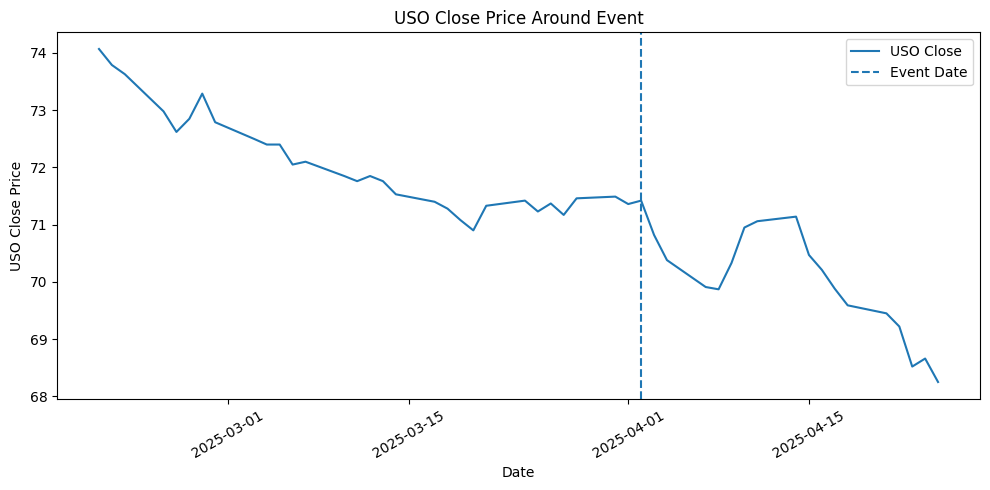

事件原始日期： 2025-04-02
使用的交易日： 2025-04-02


In [3]:
# ==============================
# 作业参考代码 1
# 绘制事件前后 30 个交易日的 USO 走势图
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

# 读取市场数据
df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])

# 设置日期索引
df = df.set_index("date")

# 事件日期：这里先用示例日期，作业时换成自己找到的事件日期
event_date = pd.to_datetime("2025-04-02")

# 只保留 USO 收盘价
uso = df[["USO_Close"]].dropna()

# 如果事件日期不是交易日，找到事件日期之后最近的交易日
future_dates = uso.index[uso.index >= event_date]

if len(future_dates) == 0:
    print("事件日期之后没有可用数据。")
else:
    event_trade_date = future_dates[0]

    # 找到事件交易日在数据中的位置
    event_position = uso.index.get_loc(event_trade_date)

    # 设置窗口：事件前 30 个交易日，事件后 30 个交易日
    start_position = max(event_position - 30, 0)
    end_position = min(event_position + 30, len(uso) - 1)

    # 截取事件附近的数据
    window_data = uso.iloc[start_position:end_position + 1]

    # 画图
    plt.figure(figsize=(10, 5))

    plt.plot(window_data.index, window_data["USO_Close"], label="USO Close")

    # 标注事件日期
    plt.axvline(x=event_trade_date, linestyle="--", label="Event Date")

    plt.title("USO Close Price Around Event")
    plt.xlabel("Date")
    plt.ylabel("USO Close Price")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print("事件原始日期：", event_date.date())
    print("使用的交易日：", event_trade_date.date())

In [4]:
# ==============================
# 作业参考代码 2
# 计算自选事件后 1、3、5 个交易日涨跌幅
# ==============================

import pandas as pd

# 读取市场数据
df = pd.read_csv("market_data_2018_2025.csv", parse_dates=["date"])
df = df.set_index("date")

# 选择需要分析的资产
price_df = df[["USO_Close", "GLD_Close", "SPY_Close"]].dropna()

# 学生自己替换成真实事件日期
events = {
    "My Event 1": "2024-03-01",
    "My Event 2": "2024-09-15",
    "My Event 3": "2025-04-02"
}

# 观察窗口：事件后 1、3、5 个交易日
windows = [1, 3, 5]

# 保存结果
results = []

for event_name, event_date in events.items():
    event_date = pd.to_datetime(event_date)

    # 找到事件日期之后最近的交易日
    future_dates = price_df.index[price_df.index >= event_date]

    if len(future_dates) == 0:
        print(event_name, "没有找到可用交易日，跳过。")
        continue

    event_trade_date = future_dates[0]

    # 事件当天价格
    base_prices = price_df.loc[event_trade_date]

    # 事件交易日的位置
    event_position = price_df.index.get_loc(event_trade_date)

    for window in windows:
        target_position = event_position + window

        if target_position >= len(price_df):
            print(event_name, window, "天后超出数据范围，跳过。")
            continue

        target_date = price_df.index[target_position]
        target_prices = price_df.iloc[target_position]

        # 计算涨跌幅
        changes = (target_prices - base_prices) / base_prices * 100

        results.append({
            "事件名称": event_name,
            "事件原始日期": event_date.date(),
            "使用交易日": event_trade_date.date(),
            "观察窗口": f"{window}个交易日后",
            "目标日期": target_date.date(),
            "USO涨跌幅%": round(changes["USO_Close"], 2),
            "GLD涨跌幅%": round(changes["GLD_Close"], 2),
            "SPY涨跌幅%": round(changes["SPY_Close"], 2)
        })

# 转成 DataFrame
result_df = pd.DataFrame(results)

print(result_df)

# 保存成 CSV，方便提交
result_df.to_csv("event_analysis_result.csv", index=False, encoding="utf-8-sig")

print("结果已保存为 event_analysis_result.csv")

         事件名称      事件原始日期       使用交易日    观察窗口        目标日期  USO涨跌幅%  GLD涨跌幅%  \
0  My Event 1  2024-03-01  2024-03-01  1个交易日后  2024-03-04     0.51    -0.12   
1  My Event 1  2024-03-01  2024-03-01  3个交易日后  2024-03-06     1.23     0.58   
2  My Event 1  2024-03-01  2024-03-01  5个交易日后  2024-03-08     1.67     1.39   
3  My Event 2  2024-09-15  2024-09-16  1个交易日后  2024-09-17     0.37     0.29   
4  My Event 2  2024-09-15  2024-09-16  3个交易日后  2024-09-19     2.02     0.98   
5  My Event 2  2024-09-15  2024-09-16  5个交易日后  2024-09-23     5.16     1.64   
6  My Event 3  2025-04-02  2025-04-02  1个交易日后  2025-04-03    -0.84     0.59   
7  My Event 3  2025-04-02  2025-04-02  3个交易日后  2025-04-07    -2.11     1.28   
8  My Event 3  2025-04-02  2025-04-02  5个交易日后  2025-04-09    -1.53     2.02   

   SPY涨跌幅%  
0     0.08  
1     0.41  
2     0.53  
3    -0.29  
4     0.03  
5     0.41  
6    -0.09  
7    -0.20  
8    -0.82  
结果已保存为 event_analysis_result.csv
